#Durabilidad de sensores
Florenca Gay Merino


## Investigacion sobre la Distribución de Weibull:

1. ¿Qué es?
La distribución de Weibull es una distribución de probabilidad continua, muy usada para modelar tiempos hasta la falla de sistemas o componentes.

Es una generalización de la exponencial: si la exponencial tiene una "tasa de fallas constante", la Weibull permite que esa tasa cambie con el tiempo.

2. Parámetros
La forma estándar tiene dos parámetros:

λ (lambda): parámetro de escala. Afecta el "tamaño" de los tiempos. A mayor λ, más "larga" la vida media.

k : parámetro de forma. Este es el más interesante porque define el comportamiento de la tasa de fallas:
$$
\begin{array}{|c|l|c|}
\hline
k & \text{Interpretación física} & \text{Tasa de fallas} \\
\hline
k < 1 & \text{Falla temprana (cada vez menos probable que falle)} & \text{Decreciente} \\
k = 1 & \text{Falla aleatoria (como la exponencial)} & \text{Constante} \\
k > 1 & \text{Falla por desgaste (cada vez más probable que falle)} & \text{Creciente} \\
\hline
\end{array}
$$
3. Funciones importantes

a) Función de densidad de probabilidad (PDF)
La función de densidad para una Weibull es:

$$f(t) = \frac{k}{\lambda} \left( \frac{t}{\lambda} \right)^{k - 1} e^{-(t/\lambda)^k}, \quad t \geq 0$$
Te da la "probabilidad relativa" de que el sensor falle justo en el tiempo t.

b) Función de distribución acumulada (CDF)
$$h(t) = \frac{f(t)}{1 - F(t)} = \frac{k}{\lambda} \left( \frac{t}{\lambda} \right)^{k - 1}$$
Es la probabilidad de que el sensor haya fallado antes o en el tiempo t.

c) Función de tasa de falla instantánea (hazard rate)
$$h(t) = \frac{f(t)}{1 - F(t)} = \frac{k}{\lambda} \left( \frac{t}{\lambda} \right)^{k - 1}$$
Esta función te dice cuán probable es que falle en un instante dado, sabiendo que hasta ese momento no falló.



###Ahora me voy a crear un grafico interativo para ver como es la funcion

In [1]:
#!pip install ipywidgets #instalar la libreria para hacerlo interactivo en caso de ser necesario.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact


colores = {
    "rosa": "#e0218a",
    "fucsia": "#ff1493",
    "azul": "#1e3a8a",
    "petrol": "#005f73",
    "rojo": "red",
    "verde": "green"
}#odio los colores de colab

#función de densidad de Weibull
def weibull_pdf(t, k, lam):
    return (k / lam)*(t / lam)**(k -1)*np.exp(-(t / lam)**k)

#función para graficar
def plot_weibull(k=1.0, lam=5000):
    t=np.linspace(0.01, 15000, 1000)
    pdf=weibull_pdf(t, k, lam)

    plt.figure(figsize=(8, 4))
    plt.plot(t,pdf,label=f"k = {k},λ= {lam}")
    plt.title("Distribución de Weibull")
    plt.xlabel("Tiempo hasta que falle (en horas)")
    plt.ylabel("Densidad de probabilidad")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Interfaz interactiva
interact(plot_weibull,
         k=widgets.FloatSlider(value=1, min=0.3, max=3, step=0.1, description='k'),
         lam=widgets.IntSlider(value=5000, min=1000, max=10000, step=500, description='λ'));



interactive(children=(FloatSlider(value=1.0, description='k', max=3.0, min=0.3), IntSlider(value=5000, descrip…

A mayor k mas se parece a una gaussiana. con k igual 1 es una exponencial decreciente

##Consigna 1: **Constante en el tiempo**
 Genere n = 100 realizaciones de una variable aleatoria con distribución de Weibull(λ = 5000, $k_0$ = 1,0) que represente el tiempo hasta la falla (en horas) de los sensores.

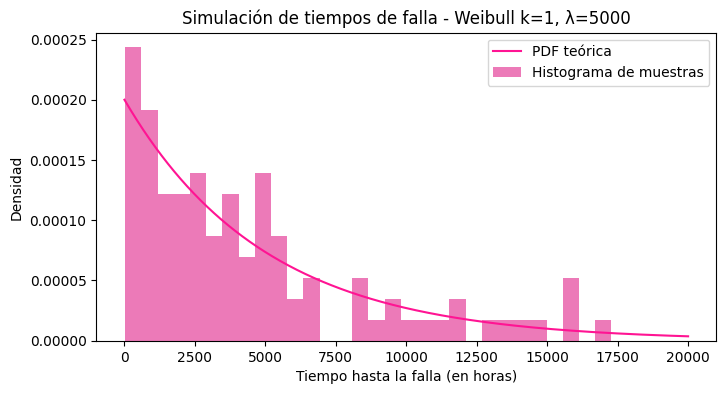

In [3]:
#@title código consigna 1
# Voy a usar scipy.stats para hacerlo.
# Documentación: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.weibull_min.html

from scipy.stats import weibull_min  # uso el _min porque es el tiempo hasta que falla

#voy a usar el rvs (Random Variates Sample) para realizarlo
k_H0 = 1
lam = 5000
n = 100
t_H0 = np.linspace(0, 20000, 1000)

np.random.seed(2001)  # para que la simulación sea siempre igual y me quede igual que en el informe si lo pongo  #es mi año de nacimiento

samples_H0 = weibull_min(c=k_H0, scale=lam).rvs(size=n)  #c equivale a k, scale a lambda y size a n

#lo grafico:
plt.figure(figsize=(8, 4))
plt.hist(samples_H0, bins=30, density=True, alpha=0.6, color=colores["rosa"])  # density=True para que normalice
plt.plot(t_H0, weibull_min(c=k_H0, scale=lam).pdf(t_H0), color=colores["fucsia"])
plt.title("Simulación de tiempos de falla - Weibull k=1, λ=5000")
plt.xlabel("Tiempo hasta la falla (en horas)")
plt.ylabel("Densidad")
plt.legend(["PDF teórica", "Histograma de muestras"])


Esta es mi $H_0$

##Consigna 2: **Decreciente en el tiempo**
 Genere ahora n = 100 realizaciones de una variable
aleatoria con distribución de Weibull(λ = 5000, $k_1$ = 0,8), que representa un escenario
donde la tasa de fallos disminuye con el tiempo.

/usr/local/lib/python3.11/dist-packages/scipy/stats/_continuous_distns.py:2757: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


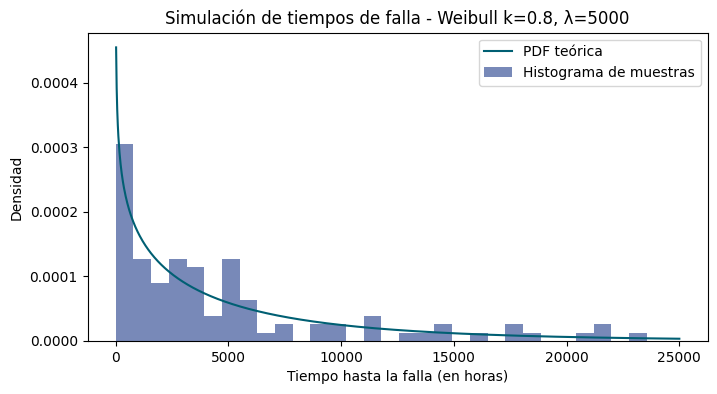

In [4]:
#@title código consigna 2
# Voy a copiar lo de arriba
k_H1 = 0.8
lam = 5000
n = 100
t_H1 = np.linspace(0, 25000, 1000)

np.random.seed(2001)

samples_H1 = weibull_min(c=k_H1, scale=lam).rvs(size=n)

# Lo grafico:
plt.figure(figsize=(8, 4))
plt.hist(samples_H1, bins=30, density=True, alpha=0.6, color=colores["azul"])
plt.plot(t_H1, weibull_min(c=k_H1, scale=lam).pdf(t_H1), color=colores["petrol"])
plt.title("Simulación de tiempos de falla - Weibull k=0.8, λ=5000")
plt.xlabel("Tiempo hasta la falla (en horas)")
plt.ylabel("Densidad")
plt.legend(["PDF teórica", "Histograma de muestras"])


Esta mi $H1$

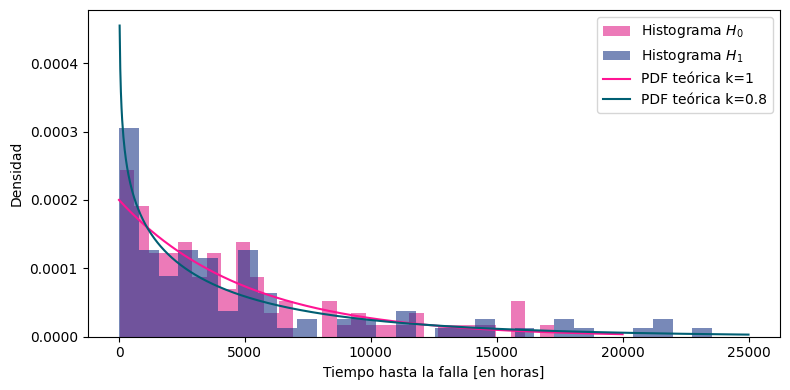

In [5]:
#@title Combino ambos gráficos
#me gustaría crearme H0 e H1 a la misma altura
plt.figure(figsize=(8, 4))
plt.hist(samples_H0, bins=30, density=True, alpha=0.6, color=colores["rosa"], label="Histograma $H_0$")
plt.hist(samples_H1, bins=30, density=True, alpha=0.6, color=colores["azul"], label="Histograma $H_1$")
plt.plot(t_H0, weibull_min(c=k_H0, scale=lam).pdf(t_H0), color=colores["fucsia"], label="PDF teórica k=1")
plt.plot(t_H1, weibull_min(c=k_H1, scale=lam).pdf(t_H1), color=colores["petrol"], label="PDF teórica k=0.8")

plt.xlabel("Tiempo hasta la falla [en horas]")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()

#con esto lo vectorizo para overleaft
plt.savefig("grafico_H0_H1.pdf", format="pdf")
plt.show()

#con esto lo vectorizo para overleaft




##Consigna 3:  **Estadístico**
 Diseñe un estadístico que permita discriminar entre las dos situaciones anteriores. Por ejemplo, puede utilizar algún estadístico que sea sensible a cambios en la
forma de la distribución (como un estimador del parámetro k) o que compare tiempos
hasta la falla temprana contra la tardía. Obtenga por simulación la distribución de este
estadístico bajo H0.

###IDEA 1: Usar MLE ($\hat{k}$)
La función `scipy.stats.weibull_min.fit()` implementa un ajuste por maximum likelihood estimation (MLE).

In [6]:
#@title idea 1
k_hat_MLE = weibull_min.fit(samples_H0, floc=0, fscale=lam)[0] #como esto es una tupla que devuelve 3 cosas, solo me intereza quedarme con el primer elemento que es el ajuste de k. (el origen y el lambda los tengo fijados)
print("k estimado con idea 1:", k_hat_MLE) #este es un solo valor, en el punto 4 voy a querer simularlo varias veces (y para eso quitarle la seed)


k estimado con idea 1: 1.0346444263714143


##Consigna 4: **Test**
 Fije un nivel de significancia α = 0,05, indique la zona de rechazo, el valor crítico y los errores tipo I y tipo II que se cometen al aplicar el test propuesto.


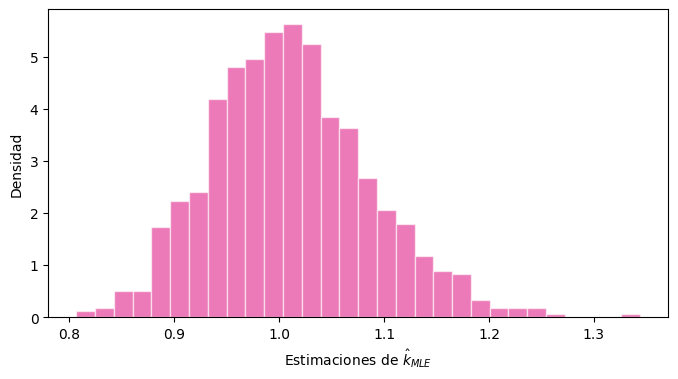

In [7]:
#@title estadístico con MLE k=1
np.random.seed(2001)
N= 1000 #numero de experimentos o simulaciones que hare

lista_mle_H0= []
for i in range(N):
  samples_H0= weibull_min(c=k_H0, scale=lam).rvs(size=n)
  k_hat_MLE_H0 = weibull_min.fit(samples_H0, floc=0, fscale=lam)[0]
  lista_mle_H0.append(k_hat_MLE_H0)

lista_mle_H0= np.array(lista_mle_H0)

#ahora grafico estos k
plt.figure(figsize=(8, 4))
plt.hist(lista_mle_H0, bins=30, density=True,alpha=0.6, color=colores["rosa"], edgecolor='white')
plt.xlabel("Estimaciones de $\\hat{k}_{MLE}$")
plt.ylabel("Densidad")
plt.show()


Genial, me dio una campana de gauss lo cual es esperable ya que al hacer tantas simulaciones de mi variable aleatoria $k$ obtengo por el TCL esta distribucion gaussiana. Encima se ve como la media esta en $k ≈ 1$.

Ahora como mi $H_1$ es que las fallas disminuyen con el tiempo, es decir  $k < 1$, mi zona de rechazo la quiero ponr solamente del lado izquierdo. La consigna me pedi un nivel de significancia del 5%, por lo que lo calculare con  `np.percentil(lista_mle,5)`

El valor crítico del estimador con MLE está en: 0.89


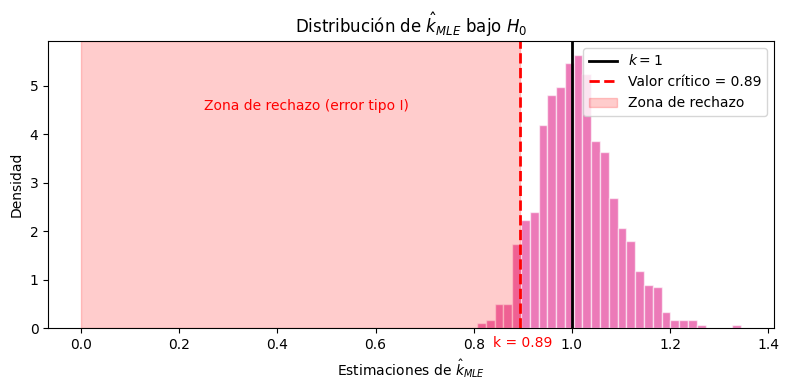

In [8]:
#@title le agrego cosas a H0
valor_critico_mle = np.percentile(lista_mle_H0, 5)
print(f"El valor crítico del estimador con MLE está en: {valor_critico_mle:.2f}")

#lo grafico
plt.figure(figsize=(8, 4))
plt.hist(lista_mle_H0, bins=30, density=True, alpha=0.6, color=colores["rosa"], edgecolor='white')
plt.axvline(x=1, color='black', linestyle='-', linewidth=2, label=r'$k = 1$') #linea vertical para el k igual 1
plt.axvline(x=valor_critico_mle, color='red', linestyle='--', linewidth=2, label=f'Valor crítico = {valor_critico_mle:.2f}') #linea vertical del valor crítico
plt.axvspan(0, valor_critico_mle, color='red', alpha=0.2, label='Zona de rechazo') #sombra
plt.ylabel("Densidad")
plt.title("Distribución de $\\hat{k}_{MLE}$ bajo $H_0$")
plt.xlabel("Estimaciones de $\\hat{k}_{MLE}$")
plt.text(0.25, 4.5, "Zona de rechazo (error tipo I)", color="red")
plt.text(0.9, -0.4, "k = 0.89", color="red", ha="center")

plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


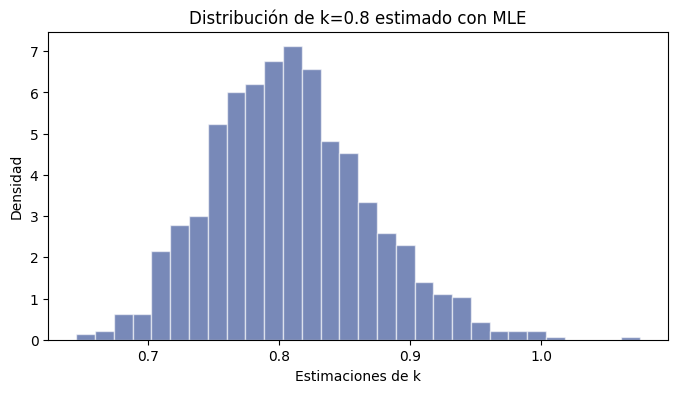

In [9]:
#@title ahora con k=0.8 simulaciones
np.random.seed(2001)
N = 1000 #numero de experimentos o simulaciones que hare

lista_mle_H1 = []
for i in range(N):
  samples_H1 = weibull_min(c=k_H1, scale=lam).rvs(size=n)
  k_hat_MLE_H1 = weibull_min.fit(samples_H1, floc=0, fscale=lam)[0]
  lista_mle_H1.append(k_hat_MLE_H1)

lista_mle_H1 = np.array(lista_mle_H1)

#ahora grafico estos k
plt.figure(figsize=(8, 4))
plt.hist(lista_mle_H1, bins=30, density=True, alpha=0.6, color=colores["azul"], edgecolor='white')
plt.title("Distribución de k=0.8 estimado con MLE")
plt.xlabel("Estimaciones de k")
plt.ylabel("Densidad")
plt.show()

In [10]:
#@title ESPERANZA y STD
mu_H0= np.mean(lista_mle_H0)
mu_H1= np.mean(lista_mle_H1)
std_H0= np.std(lista_mle_H0)
std_H1= np.std(lista_mle_H1)

print(f"Media H0: {mu_H0:.2f}")
print(f"Media H1: {mu_H1:.2f}")
print(f"Desviación estándar H0: {std_H0:.2f}")
print(f"Desviación estándar H1: {std_H1:.2f}")


Media H0: 1.01
Media H1: 0.81
Desviación estándar H0: 0.08
Desviación estándar H1: 0.06


In [11]:
#@title cuanto vale beta?
beta = np.mean(lista_mle_H1 >= valor_critico_mle)
print(f"Error tipo II (beta): {beta:.2f}")

Error tipo II (beta): 0.09


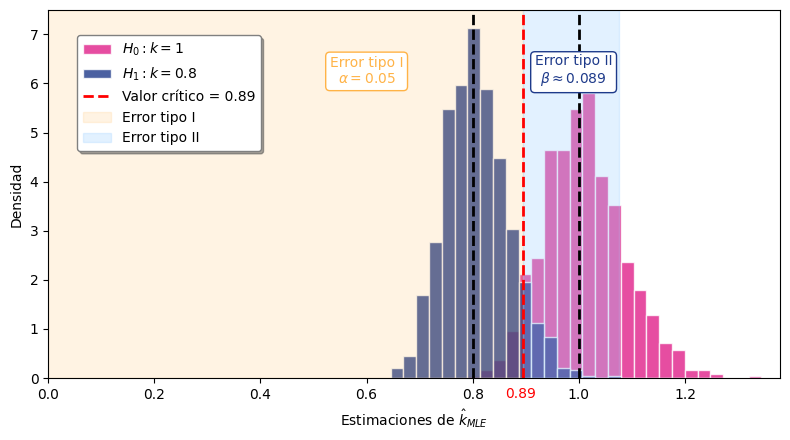

In [12]:
#@title  Gráfico conjunto
plt.figure(figsize=(8, 4.5))
bins = np.linspace(min(min(lista_mle_H0), min(lista_mle_H1)),
                   max(max(lista_mle_H0), max(lista_mle_H1)), 30)

plt.hist(lista_mle_H0, bins=bins, density=True, alpha=0.8, label=r"$H_0: k=1$", color=colores["rosa"], edgecolor="white")
plt.hist(lista_mle_H1, bins=bins, density=True, alpha=0.8, label=r"$H_1: k=0.8$", color=colores["azul"], edgecolor="white")

plt.axvline(x=valor_critico_mle, color='red', linestyle='--', linewidth=2, label=f"Valor crítico = {valor_critico_mle:.2f}")
plt.axvline(x=0.8, color="black", linestyle='--', linewidth=2)#, label = rf"$\mathbb{{E}}[\hat{{k}}_{{\text{{MLE}}}}] = {mu_H0:.2f}$")
plt.axvline(x=1, color="black", linestyle='--', linewidth=2)#, label=rf"$\mathbb{{E}}[\hat{{k}}_{{\text{{MLE}}}}] = {mu_H1:.2f}$")
plt.xlim(left=0)

# Zona de rechazo (error tipo I bajo H0)
plt.axvspan(0, valor_critico_mle, color="#ffb347", alpha=0.15, label="Error tipo I")

plt.text(
    0.6, 6, "Error tipo I\n$\\alpha=0.05$", color="#ffb347", ha="center",
    bbox=dict(facecolor='white', edgecolor="#ffb347", boxstyle='round,pad=0.3')
)
plt.text(0.89, -0.40, "0.89", color="red", ha="center")

# Zona de error tipo II bajo H1
plt.axvspan(valor_critico_mle, max(lista_mle_H1), color="#a2d2ff", alpha=0.3, label="Error tipo II")
plt.text(
    0.99, 6, f"Error tipo II\n$\\beta \\approx {beta:.3f}$", color=colores["azul"], ha="center",
    bbox=dict(facecolor='white', edgecolor=colores["azul"], boxstyle='round,pad=0.3')
)

#plt.title("Distribución de $\hat{\\alpha}_{MLE}$ bajo $H_0$ y $H_1$")
plt.xlabel("Estimaciones de $\\hat{k}_{MLE}$")
plt.ylabel("Densidad")
plt.legend(
    bbox_to_anchor=(0.3, 0.95),
    frameon=True,
    facecolor="white",
    edgecolor="grey",
    framealpha=1,
    fontsize=10,
    fancybox=True,
    shadow=True
)
plt.tight_layout()
plt.savefig("grafico_k_estimadores.pdf", format="pdf",bbox_inches='tight')
plt.show()



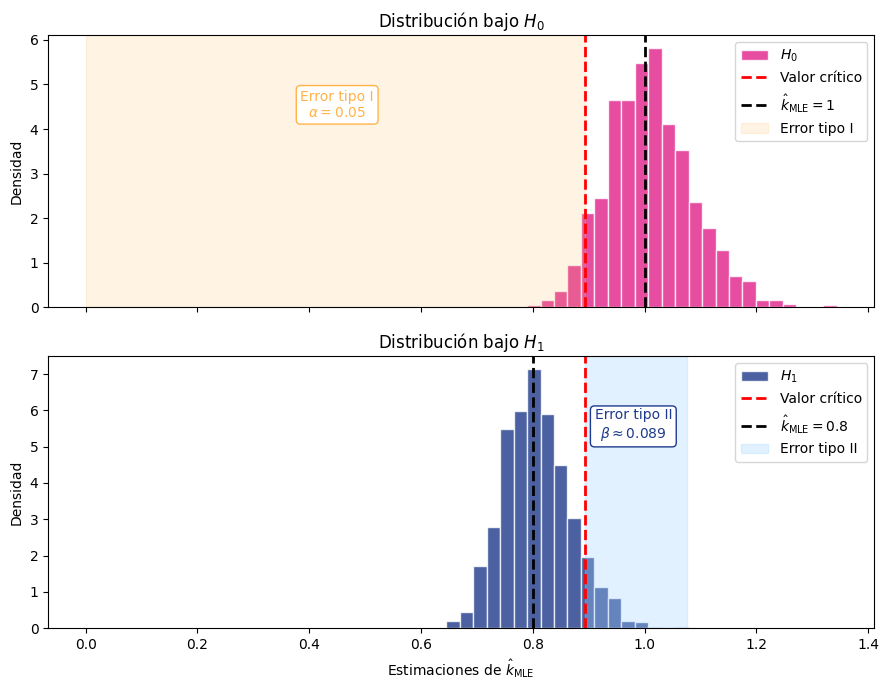

In [13]:
#@title uno abajo del otro para verlo de otra forma (no lo use al final)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

bins = np.linspace(min(min(lista_mle_H0), min(lista_mle_H1)),
                   max(max(lista_mle_H0), max(lista_mle_H1)), 30)

#h0
ax1.hist(lista_mle_H0, bins=bins, density=True, alpha=0.8, label=r"$H_0$", color=colores["rosa"], edgecolor="white")
ax1.axvline(x=valor_critico_mle, color='red', linestyle='--', linewidth=2, label="Valor crítico")
ax1.axvline(x=1, color="black", linestyle='--', linewidth=2, label=r"$\hat{k}_{\mathrm{MLE}} = 1$")

ax1.axvspan(0, valor_critico_mle, color="#ffb347", alpha=0.15, label="Error tipo I")
ax1.text(0.45, ax1.get_ylim()[1]*0.7, "Error tipo I\n$\\alpha = 0.05$", color="#ffb347", ha="center",
         bbox=dict(facecolor='white', edgecolor="#ffb347", boxstyle='round,pad=0.3'))

ax1.set_ylabel("Densidad")
ax1.set_title("Distribución bajo $H_0$")
ax1.legend(loc='upper right')

#h1
ax2.hist(lista_mle_H1, bins=bins, density=True, alpha=0.8, label=r"$H_1$", color=colores["azul"], edgecolor="white")
ax2.axvline(x=valor_critico_mle, color='red', linestyle='--', linewidth=2, label="Valor crítico")
ax2.axvline(x=0.8, color="black", linestyle='--', linewidth=2, label=r"$\hat{k}_{\mathrm{MLE}} = 0.8$")

ax2.axvspan(valor_critico_mle, max(lista_mle_H1), color="#a2d2ff", alpha=0.3, label="Error tipo II")
ax2.text(0.98, ax2.get_ylim()[1]*0.7, f"Error tipo II\n$\\beta \\approx {beta:.3f}$", color=colores["azul"], ha="center",
         bbox=dict(facecolor='white', edgecolor=colores["azul"], boxstyle='round,pad=0.3'))

ax2.set_xlabel("Estimaciones de $\\hat{k}_{\\mathrm{MLE}}$")
ax2.set_ylabel("Densidad")
ax2.set_title("Distribución bajo $H_1$")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


##Consigna 5: **Potencia**
 Calcule la potencia del test para distintos valores de k1 ∈ { 1,0, 0,95, 0,9, 0,85, 0,8, 0,75, 0,7, 0,65, 0,6, 0,5 }.

Muestre los resultados en un gráfico potencia vs. k1.

In [14]:
#@title MLE (tarda un porquito el código je)
np.random.seed(2001)
ks = [1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.5]
potencias = []

for j in ks:
  lista_ks_hats = []
  for i in range(N):
    samples_Hi = weibull_min(c=j, scale=lam).rvs(size=n)
    k_hat_MLE_Hi = weibull_min.fit(samples_Hi, floc=0, fscale=lam)[0]
    lista_ks_hats.append(k_hat_MLE_Hi)
  beta = np.mean(np.array(lista_ks_hats) >= valor_critico_mle)
  potencia = 1 - beta
  potencias.append(potencia)
  print(f"k = {j:.2f} → Potencia = {potencia:.2f}")

ks = np.array(ks)
potencias = np.array(potencias)


k = 1.00 → Potencia = 0.05
k = 0.95 → Potencia = 0.20
k = 0.90 → Potencia = 0.45
k = 0.85 → Potencia = 0.74
k = 0.80 → Potencia = 0.93
k = 0.75 → Potencia = 0.98
k = 0.70 → Potencia = 1.00
k = 0.65 → Potencia = 1.00
k = 0.60 → Potencia = 1.00
k = 0.50 → Potencia = 1.00


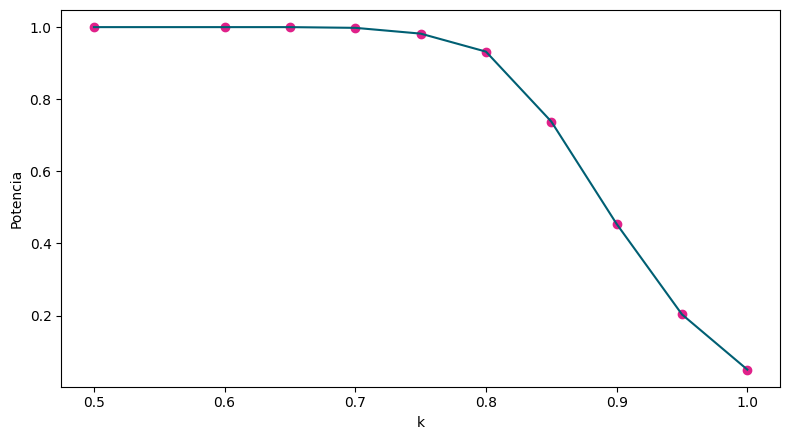

In [15]:
plt.figure(figsize=(8, 4.5))
plt.scatter(ks, potencias, color=colores["rosa"])
plt.plot(ks, potencias,color= colores["petrol"])
plt.xlabel("k")
plt.ylabel("Potencia")
plt.tight_layout()
plt.savefig("grafico_potencia1.pdf", format="pdf")
plt.show()



##Consigna 6: **p-valor**
Simule una muestra de n = 100 sensores con k1 = 0,90. Aplique el test y
calcule el p-valor. ¿Cuál es la máxima significancia que le podríamos pedir al test tal
que no rechace la hipótesis nula?


In [16]:
np.random.seed(2001)
k_alt = 0.9 #si lo cambio a k=1 el p-valor se muestra uniforme

samples_H_alt = weibull_min(c=k_alt, scale=lam).rvs(size=n)
k_hat_alt = weibull_min.fit(samples_H_alt, floc=0, fscale=lam)[0]

p_valor = np.mean(lista_mle_H0 <= k_hat_alt)
alpha_max = p_valor#es justo el p-valor obtenido
print(f"Máxima significancia para no rechazar H0: {alpha_max:.3f}") #cambia cuando cambia la seed



Máxima significancia para no rechazar H0: 0.136


##Consigna 7:  **Histograma de p-valores**
Repita 1000 veces el paso anterior y grafique el histograma
de los p-valores. Discuta qué se espera ver si la hipótesis nula es cierta y qué diferencias
aparecen cuando k1 < 1

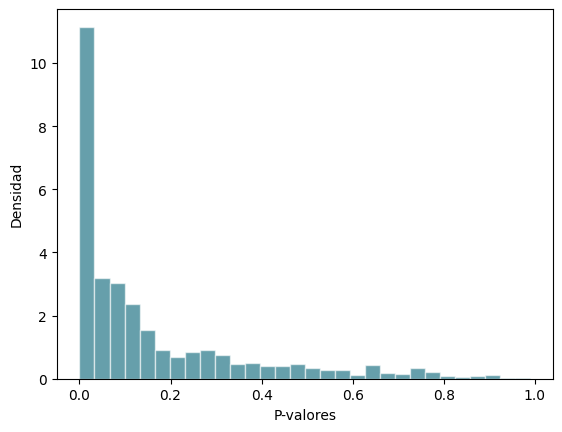

In [17]:
lista_estadistico_alt = []
for i in range(N):
  samples_H_alt = weibull_min(c=k_alt, scale=lam).rvs(size=n)
  k_hat_alt = weibull_min.fit(samples_H_alt, floc=0, fscale=lam)[0]
  lista_estadistico_alt.append(k_hat_alt)

#ahora calculo el p-valor para cada uno.
p_valores = []
for j in lista_estadistico_alt:
  p_valor = np.mean(lista_mle_H0 <= j)
  p_valores.append(p_valor)

p_valores = np.array(p_valores)

plt.hist(p_valores, bins=30, density=True, alpha=0.6, color=colores["petrol"], edgecolor='white')
plt.xlabel("P-valores")
plt.ylabel("Densidad")
plt.savefig("grafico_p_valor_09.pdf", format="pdf")
plt.show()



El valor crítico del estimador con MLE está en: 0.894
Máxima significancia para no rechazar H0: 0.655


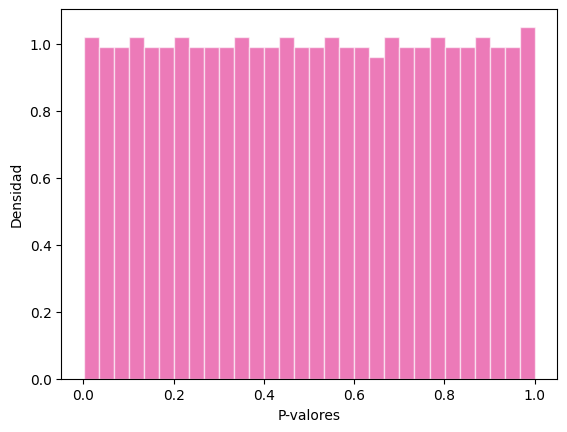

In [18]:
#@title para para la hipotesis nula
k_H0 = 1

np.random.seed(2001)

samples_H0 = weibull_min(c=k_H0, scale=lam).rvs(size=n)
k_hat_H0 = weibull_min.fit(samples_H0, floc=0, fscale=lam)[0]

P_valor_1= np.percentile(lista_mle_H0, 5)
print(f"El valor crítico del estimador con MLE está en: {P_valor_1:.3f}")


p_valor = np.mean(lista_mle_H0 <= k_hat_H0)
alpha_max = p_valor#es justo el p-valor obtenido
print(f"Máxima significancia para no rechazar H0: {alpha_max:.3f}") #cambia cuando cambia la seed

lista_estadistico_H0 = []
for i in range(N):
  samples_H0 = weibull_min(c=k_H0, scale=lam).rvs(size=n)
  k_hat_H0 = weibull_min.fit(samples_H0, floc=0, fscale=lam)[0]
  lista_estadistico_H0.append(k_hat_H0)

#ahora calculo el p-valor para cada uno.
p_valores_H0 = []
for j in lista_estadistico_H0:
  p_valor = np.mean(lista_mle_H0 <= j)
  p_valores_H0.append(p_valor)

p_valores_H0 = np.array(p_valores_H0)

plt.hist(p_valores_H0, bins=30, density=True, alpha=0.6, color=colores["rosa"], edgecolor='white')
plt.xlabel("P-valores")
plt.ylabel("Densidad")
plt.savefig("grafico_p_valor_1.pdf", format="pdf")
plt.show()


